In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

In [2]:
urls = {
    "advanced": "https://raw.githubusercontent.com/NREL/ReEDS-2.0/refs/heads/main/inputs/plant_characteristics/battery_ATB_2024_advanced.csv",
    "moderate": "https://raw.githubusercontent.com/NREL/ReEDS-2.0/refs/heads/main/inputs/plant_characteristics/battery_ATB_2024_moderate.csv",
    "conservative": "https://raw.githubusercontent.com/NREL/ReEDS-2.0/refs/heads/main/inputs/plant_characteristics/battery_ATB_2024_conservative.csv",
}

In [3]:
dfs = []
for scenario, url in urls.items():
    df = pd.read_csv(url)
    df["scenario"] = scenario
    dfs.append(df)

battery_atb = pd.concat(dfs, ignore_index=True)

# Optional: ensure year is numeric and sort
battery_atb["t"] = pd.to_numeric(battery_atb["t"], errors="coerce")
battery_atb = battery_atb.sort_values(["scenario", "t"]).reset_index(drop=True)

print(battery_atb.head())
print("Rows:", len(battery_atb), "Cols:", battery_atb.shape[1])




            i     t  capcost  capcost_energy   fom  fom_energy  vom   rte  \
0  battery_li  2010   363.01          390.93  9.08        9.77    0  0.85   
1  battery_li  2011   363.01          390.93  9.08        9.77    0  0.85   
2  battery_li  2012   363.01          390.93  9.08        9.77    0  0.85   
3  battery_li  2013   363.01          390.93  9.08        9.77    0  0.85   
4  battery_li  2014   363.01          390.93  9.08        9.77    0  0.85   

   scenario  
0  advanced  
1  advanced  
2  advanced  
3  advanced  
4  advanced  
Rows: 123 Cols: 9


In [4]:
battery = pd.concat(dfs, ignore_index=True)
battery["t"] = pd.to_numeric(battery["t"], errors="coerce")
battery = battery.sort_values(["scenario", "t"]).reset_index(drop=True)

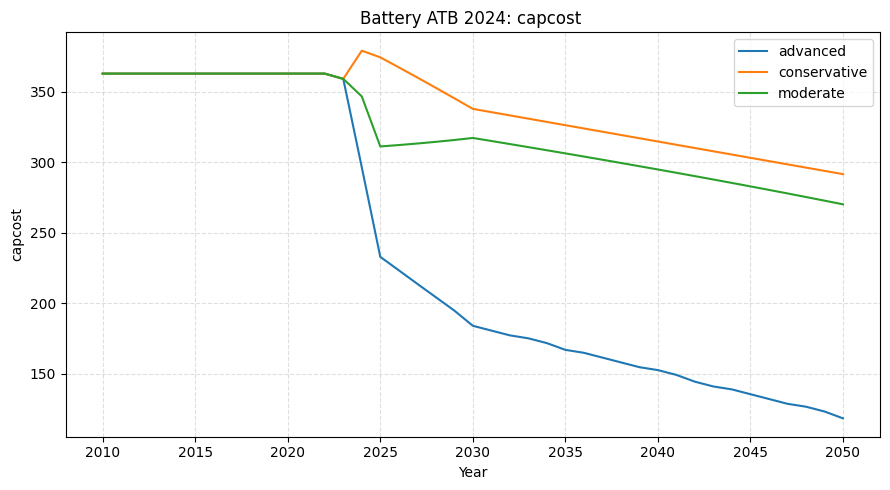

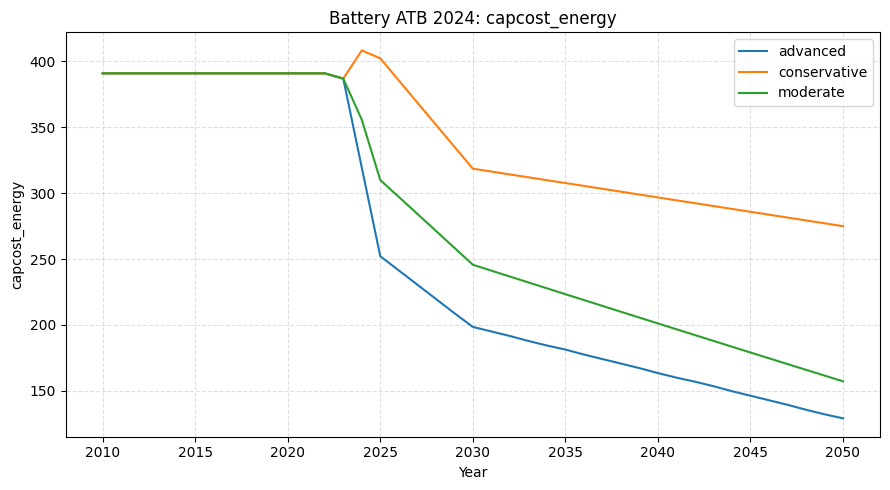

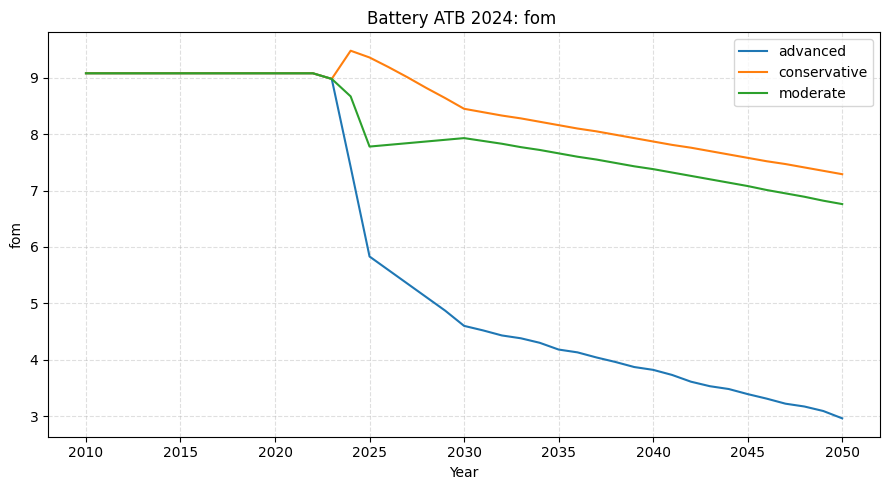

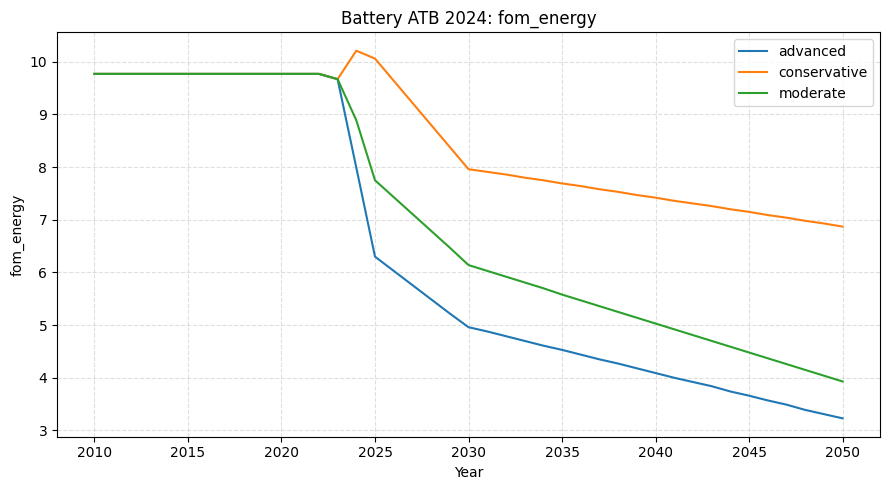

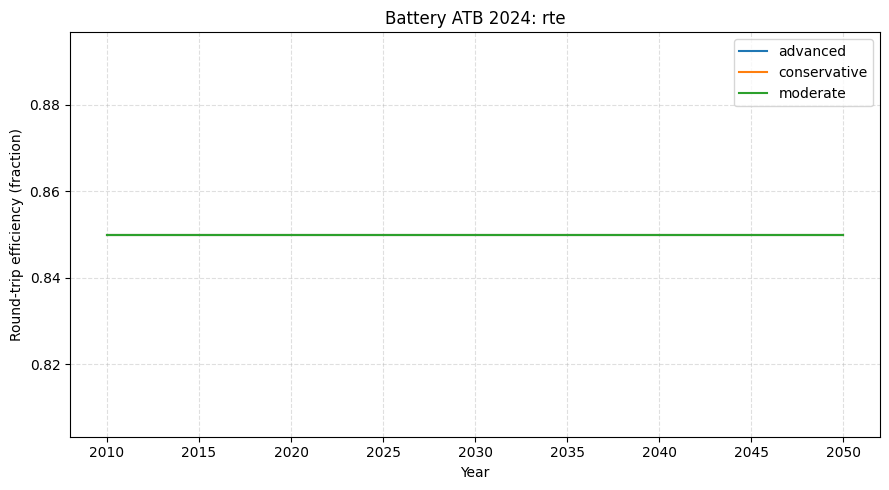

In [5]:
# --- Helper to plot any metric vs year ---
def plot_metric(df, metric, ylabel=None, title=None):
    plt.figure(figsize=(9, 5))
    for scen, g in df.groupby("scenario"):
        g = g.sort_values("t")
        plt.plot(g["t"], g[metric], label=scen)
    plt.xlabel("Year")
    plt.ylabel(ylabel if ylabel else metric)
    plt.title(title if title else metric)
    plt.grid(True, linestyle="--", alpha=0.4)
    plt.legend()
    plt.tight_layout()
    plt.show()

# --- Core visualizations ---
plot_metric(battery, "capcost", ylabel="capcost", title="Battery ATB 2024: capcost ")
plot_metric(battery, "capcost_energy", ylabel="capcost_energy", title="Battery ATB 2024: capcost_energy")
plot_metric(battery, "fom", ylabel="fom", title="Battery ATB 2024: fom ")
plot_metric(battery, "fom_energy", ylabel="fom_energy", title="Battery ATB 2024: fom_energy")
plot_metric(battery, "rte", ylabel="Round-trip efficiency (fraction)", title="Battery ATB 2024: rte")




In [6]:
# # --- Optional: percent change vs first year (helps compare trends) ---
# def plot_pct_change_from_first_year(df, metric):
#     plt.figure(figsize=(9, 5))
#     for scen, g in df.groupby("scenario"):
#         g = g.sort_values("t").dropna(subset=["t", metric])
#         base = g[metric].iloc[0]
#         pct = (g[metric] / base - 1.0) * 100.0
#         plt.plot(g["t"], pct, label=scen)
#     plt.xlabel("Year")
#     plt.ylabel(f"{metric}: % change vs first year")
#     plt.title(f"Battery ATB 2024: {metric} (% change vs first year)")
#     plt.grid(True, linestyle="--", alpha=0.4)
#     plt.legend()
#     plt.tight_layout()
#     plt.show()

# plot_pct_change_from_first_year(battery, "capcost")
# plot_pct_change_from_first_year(battery, "capcost_energy")
# plot_pct_change_from_first_year(battery, "fom")
# plot_pct_change_from_first_year(battery, "fom_energy")

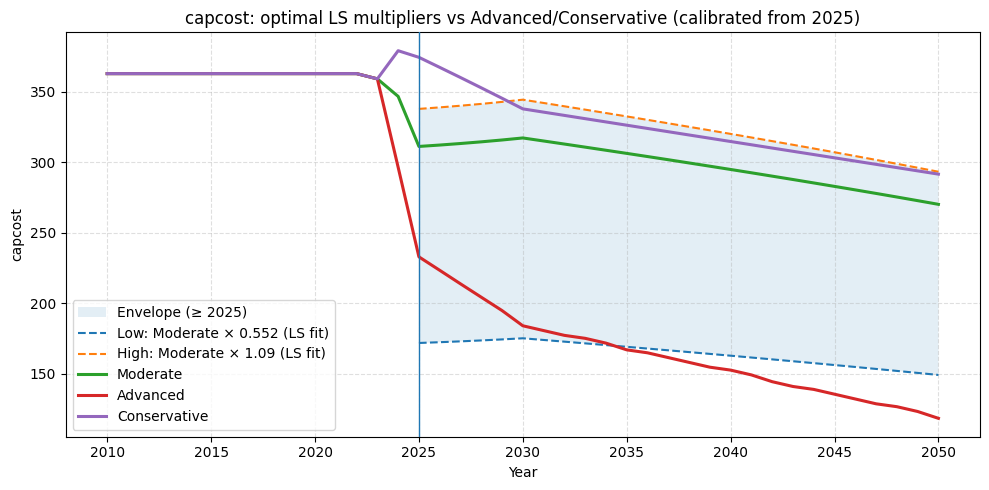

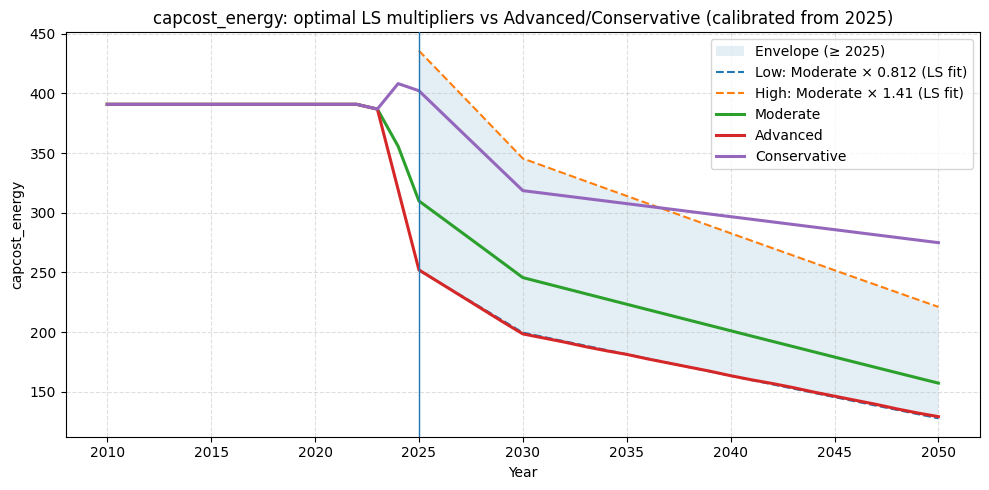

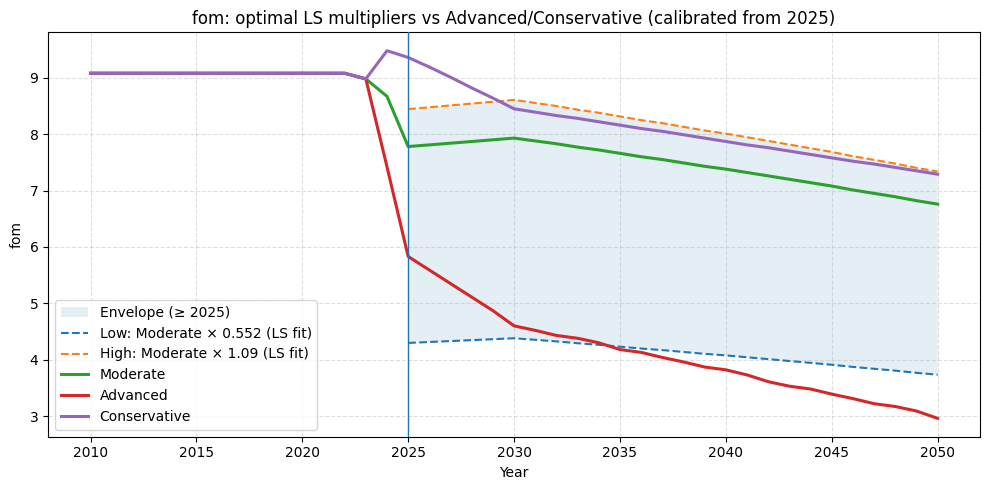

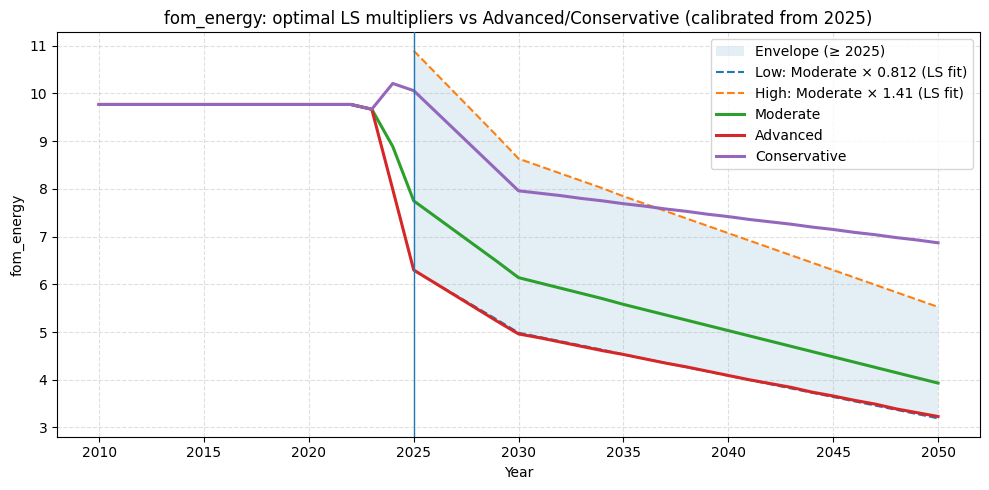

,metric,mA,mC,low_mult,high_mult
0,capcost,0.552367,1.085522,0.552367,1.085522
1,capcost_energy,0.812351,1.406279,0.812351,1.406279
2,fom,0.552358,1.085444,0.552358,1.085444
3,fom_energy,0.812012,1.406020,0.812012,1.406020


In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def fit_multiplier_ls(M, Y):
    # m = argmin ||m*M - Y||^2 = (M·Y)/(M·M)
    Mv = M.values
    Yv = Y.values
    return float(np.dot(Mv, Yv) / np.dot(Mv, Mv))

def plot_full_scenarios_with_optimal_envelope(df, metric, start_year=2025, eps=1e-12):
    piv = (df[["t", "scenario", metric]]
           .dropna(subset=["t", metric])
           .assign(t=lambda x: pd.to_numeric(x["t"], errors="coerce"))
           .dropna(subset=["t"])
           .pivot(index="t", columns="scenario", values=metric)
           .sort_index())

    piv_cal = piv.loc[piv.index >= start_year]

    # Use lowercase scenario names as they exist in the 'piv_cal' DataFrame
    M = piv_cal["moderate"]
    A = piv_cal["advanced"]
    C = piv_cal["conservative"]

    mA = fit_multiplier_ls(M, A)
    mC = fit_multiplier_ls(M, C)

    mult_low = min(mA, mC)
    mult_high = max(mA, mC)

    # Use lowercase scenario names
    env_low = (piv["moderate"] * mult_low).where(piv.index >= start_year, np.nan)
    env_high = (piv["moderate"] * mult_high).where(piv.index >= start_year, np.nan)

    plt.figure(figsize=(10, 5))

    # envelope behind
    plt.fill_between(env_low.index, env_low.values, env_high.values, alpha=0.12, zorder=1,
                     label=f"Envelope (≥ {start_year})")
    plt.plot(env_low.index, env_low.values, "--", zorder=2,
             label=f"Low: Moderate × {mult_low:.3g} (LS fit)")
    plt.plot(env_high.index, env_high.values, "--", zorder=2,
             label=f"High: Moderate × {mult_high:.3g} (LS fit)")

    # full scenario lines on top (use lowercase scenario names)
    plt.plot(piv.index, piv["moderate"], linewidth=2.2, zorder=5, label="Moderate")
    plt.plot(piv.index, piv["advanced"], linewidth=2.2, zorder=5, label="Advanced")
    plt.plot(piv.index, piv["conservative"], linewidth=2.2, zorder=5, label="Conservative")

    plt.axvline(start_year, linewidth=1, zorder=6)
    plt.title(f"{metric}: optimal LS multipliers vs Advanced/Conservative (calibrated from {start_year})")
    plt.xlabel("Year")
    plt.ylabel(metric)
    plt.grid(True, linestyle="--", alpha=0.4)
    plt.legend()
    plt.tight_layout()
    plt.show()

    return {"metric": metric, "mA": mA, "mC": mC, "low_mult": mult_low, "high_mult": mult_high}

# Run for your metrics
results = []
for m in ["capcost", "capcost_energy", "fom", "fom_energy"]:
    results.append(plot_full_scenarios_with_optimal_envelope(battery, m, start_year=2025))

pd.DataFrame(results)

In [8]:
import os
import numpy as np
import pandas as pd

# ============================================================
# Create per-sample Battery ATB CSVs (capcost & capcost_energy sampled)
# fom and fom_energy = 2.5% of the updated cap costs
# Apply sampling only from START_YEAR onward (default 2025)
# ============================================================

START_YEAR = 2025
FIXED_OM_FRAC = 0.025  # 2.5%

# ---- (A) Load your sample set ----
# Expected columns (edit names if yours differ):
#   run_id, capcost_mult, capcost_energy_mult
#
# Example:
# samples_df = pd.read_csv("my_battery_samples.csv")
#
# If you already created it in-notebook, just set samples_df = <that dataframe>

# >>> REPLACE THIS with your real samples_df <<<
samples_df = pd.DataFrame({
    "run_id": [1,2,3],
    "capcost_mult": [0.95, 1.10, 1.02],
    "capcost_energy_mult": [0.90, 1.15, 1.05],
})

required_cols = ["run_id", "capcost_mult", "capcost_energy_mult"]
missing = [c for c in required_cols if c not in samples_df.columns]
if missing:
    raise ValueError(f"samples_df is missing columns: {missing}. Found: {list(samples_df.columns)}")

# ---- (B) Choose the BASE series (moderate) to expand ----
# df_moderate is already built in your notebook.
df_moderate = next((df for df in dfs if 'scenario' in df.columns and (df['scenario'] == 'moderate').any()), None)

if df_moderate is None:
    raise ValueError("Could not find 'moderate' scenario dataframe in `dfs`.")

base = df_moderate.copy()

needed_base_cols = ["t", "capcost", "capcost_energy", "vom", "rte"]
missing_base = [c for c in needed_base_cols if c not in base.columns]
if missing_base:
    raise ValueError(f"Base df is missing columns: {missing_base}. Found: {list(base.columns)}")

# Ensure year int
base["t"] = base["t"].astype(int)

# Some files have "i" tech column. Keep it if present.
has_i = "i" in base.columns

# ---- (C) Helper to apply a sample to the base series ----
def apply_sample_to_base(
    base_df: pd.DataFrame,
    cap_mult: float,
    capE_mult: float,
    start_year: int = 2025,
    fixed_om_frac: float = 0.025
) -> pd.DataFrame:
    out = base_df.copy()

    # multipliers apply only for years >= start_year
    mask = out["t"] >= start_year
    out.loc[mask, "capcost"] = out.loc[mask, "capcost"].astype(float) * float(cap_mult)
    out.loc[mask, "capcost_energy"] = out.loc[mask, "capcost_energy"].astype(float) * float(capE_mult)

    # enforce the pattern you observed: fom and fom_energy = 2.5% of capex
    out["fom"] = fixed_om_frac * out["capcost"].astype(float)
    out["fom_energy"] = fixed_om_frac * out["capcost_energy"].astype(float)

    return out

# ---- (D) Write one CSV per run ----
out_dir = "battery_samples_out"
os.makedirs(out_dir, exist_ok=True)

written = []
for _, row in samples_df.iterrows():
    run_id = row["run_id"]
    cap_mult = row["capcost_mult"]
    capE_mult = row["capcost_energy_mult"]

    df_run = apply_sample_to_base(
        base_df=base,
        cap_mult=cap_mult,
        capE_mult=capE_mult,
        start_year=START_YEAR,
        fixed_om_frac=FIXED_OM_FRAC
    )

    # Keep only the columns ReEDS expects (and keep i if present)
    cols_out = (["i"] if has_i else []) + ["t", "capcost", "capcost_energy", "fom", "fom_energy", "vom", "rte"]
    df_run = df_run[cols_out]

    fname = f"battery_ATB_2024_run{int(run_id):03d}.csv"
    fpath = os.path.join(out_dir, fname)
    df_run.to_csv(fpath, index=False)

    written.append((run_id, fname, cap_mult, capE_mult))

# quick summary
summary = pd.DataFrame(written, columns=["run_id", "file", "capcost_mult", "capcost_energy_mult"])
print("Wrote", len(summary), "files to:", out_dir)
display(summary.head(10))

print("\nMultiplier ranges (from your samples_df):")
print("capcost_mult:        ", (summary["capcost_mult"].min(), summary["capcost_mult"].max()))
print("capcost_energy_mult: ", (summary["capcost_energy_mult"].min(), summary["capcost_energy_mult"].max()))

Wrote 3 files to: battery_samples_out


,run_id,file,capcost_mult,capcost_energy_mult
0,1.0,battery_ATB_2024_run001.csv,0.95,0.90
1,2.0,battery_ATB_2024_run002.csv,1.10,1.15
2,3.0,battery_ATB_2024_run003.csv,1.02,1.05



Multiplier ranges (from your samples_df):
capcost_mult:         (0.95, 1.1)
capcost_energy_mult:  (0.9, 1.15)


In [9]:
from IPython.display import Markdown, display
import pandas as pd

results_df = pd.DataFrame(results)

# Keep only these two metrics
keep = {"capcost", "capcost_energy"}
results_sub = results_df[results_df["metric"].isin(keep)].copy()

metric_units = {
    "capcost": r"\$/MW",          # power capacity cost (adjust if your file is $/kW)
    "capcost_energy": r"\$/MWh",  # energy capacity cost
}

latex_rows = []
for _, row in results_sub.iterrows():
    metric = row["metric"]
    low_mult = row["low_mult"]
    high_mult = row["high_mult"]

    parameter = rf"Battery -- {metric}"
    unit = metric_units.get(metric, "unitless")

    latex_rows.append(
        rf"{parameter} & {high_mult:.4f} & {low_mult:.4f} & {unit} (multiplier) \\"
    )

full_latex_table = rf"""
\begin{{table}}[h!]
\centering
\caption{{Multiplier Bounds and Units for Battery Capital Cost Metrics (ATB 2024)}}
\label{{tab:battery_capcost_bounds_units}}
\begin{{tabular}}{{l c c c}}
\toprule
Parameter & Upperbound & Lowerbound & Unit \\
\midrule
{chr(10).join(latex_rows)}
\bottomrule
\end{{tabular}}
\end{{table}}
"""

display(Markdown(f"```latex\n{full_latex_table}\n```"))




```latex

\begin{table}[h!]
\centering
\caption{Multiplier Bounds and Units for Battery Capital Cost Metrics (ATB 2024)}
\label{tab:battery_capcost_bounds_units}
\begin{tabular}{l c c c}
\toprule
Parameter & Upperbound & Lowerbound & Unit \\
\midrule
Battery -- capcost & 1.0855 & 0.5524 & \$/MW (multiplier) \\
Battery -- capcost_energy & 1.4063 & 0.8124 & \$/MWh (multiplier) \\
\bottomrule
\end{tabular}
\end{table}

```

In [10]:
import numpy as np
import pandas as pd
from pathlib import Path

# ============================================================
# Battery ATB 2024 — generate ONE ReEDS-format CSV per Morris row
#   - Uses your Morris design + factor map from GitHub
#   - Applies multipliers ONLY for years >= START_YEAR
#   - Enforces: fom = 2.5% * capcost, fom_energy = 2.5% * capcost_energy
#   - Writes N files (e.g., 200) with EXACT same columns/order as base file
# ============================================================

# -----------------------
# (0) CONFIG
# -----------------------
START_YEAR = 2025
FIXED_OM_FRAC = 0.025  # 2.5%

MORRIS_DESIGN_URL = "https://raw.githubusercontent.com/Raziye-Aghapour/ReEDS_Morris/refs/heads/main/morris_design_r5_p6.csv#/"
FACTOR_MAP_URL    = "https://raw.githubusercontent.com/Raziye-Aghapour/ReEDS_Morris/refs/heads/main/morris_factor_map.csv#/"

# Output folder
OUTDIR = Path("battery_ATB_2024_morris_outputs")
OUTDIR.mkdir(parents=True, exist_ok=True)

# -----------------------
# (1) LOAD MORRIS FILES
# -----------------------
design = pd.read_csv(MORRIS_DESIGN_URL)
factor_map = pd.read_csv(FACTOR_MAP_URL)

# Keep only the two battery factors we need
BATTERY_FACTORS = ["battery_capcost", "battery_capcost_energy"]

missing_cols = [c for c in BATTERY_FACTORS if c not in design.columns]
if missing_cols:
    raise ValueError(
        f"Morris design is missing required battery columns: {missing_cols}\n"
        f"Columns found: {list(design.columns)}"
    )

# Optional: grab bounds from factor_map (for sanity checks)
fm = factor_map.set_index("factor")
for f in BATTERY_FACTORS:
    if f not in fm.index:
        raise ValueError(f"Factor '{f}' not found in factor_map. Found {len(fm)} factors.")

bounds = {
    f: (float(fm.loc[f, "Lowerbound"]), float(fm.loc[f, "Upperbound"]))
    for f in BATTERY_FACTORS
}

# -----------------------
# (2) LOAD BASE (REFERENCE) BATTERY FILE
#     Must match NREL "moderate" format exactly.
#     If you already have the moderate battery df in-memory, set BASE_DF = that.
# -----------------------
BASE_DF = None

# If you already have a battery moderate dataframe in your notebook, uncomment ONE:
# BASE_DF = df_moderate.copy()     # if you used this name
# BASE_DF = battery_base.copy()    # if you used this name
# BASE_DF = base.copy()            # if you used this name

if BASE_DF is None:
    # Try a few likely NREL paths automatically (first one that works wins)
    candidate_urls = [
        # Common naming patterns in ReEDS plant_characteristics
        "https://raw.githubusercontent.com/NREL/ReEDS-2.0/refs/heads/main/inputs/plant_characteristics/battery_li_ATB_2024_moderate.csv",
        "https://raw.githubusercontent.com/NREL/ReEDS-2.0/refs/heads/main/inputs/plant_characteristics/battery_ATB_2024_moderate.csv",
        "https://raw.githubusercontent.com/NREL/ReEDS-2.0/refs/heads/main/inputs/plant_characteristics/battery_ATB_2024.csv",
        "https://raw.githubusercontent.com/NREL/ReEDS-2.0/refs/heads/main/inputs/plant_characteristics/battery_li_ATB_2024.csv",
    ]
    last_err = None
    for u in candidate_urls:
        try:
            tmp = pd.read_csv(u)
            # Require the expected columns so we don’t accidentally load the wrong file
            needed = {"t", "capcost", "capcost_energy", "fom", "fom_energy", "vom", "rte"}
            if not needed.issubset(set(tmp.columns)):
                raise ValueError(f"Loaded but missing columns: {sorted(list(needed - set(tmp.columns)))}")
            BASE_DF = tmp
            print(f"Loaded base battery file from: {u}")
            break
        except Exception as e:
            last_err = e
            continue

    if BASE_DF is None:
        raise RuntimeError(
            "Could not auto-load the NREL base battery moderate CSV.\n"
            "Please set BASE_DF to your already-loaded moderate battery dataframe, OR set a correct base URL.\n"
            f"Last error: {last_err}"
        )

# Ensure types
BASE_DF = BASE_DF.copy()
BASE_DF["t"] = pd.to_numeric(BASE_DF["t"], errors="raise").astype(int)

# Preserve EXACT column order from NREL base (this is what prevents ReEDS input errors)
base_col_order = list(BASE_DF.columns)

# Optional: keep tech column if present (often 'i')
has_i = "i" in BASE_DF.columns

# -----------------------
# (3) APPLY ONE MORRIS ROW -> ONE OUTPUT CSV
# -----------------------
def apply_battery_morris_row(base_df: pd.DataFrame, cap_mult: float, capE_mult: float) -> pd.DataFrame:
    out = base_df.copy()

    # Apply multipliers only for years >= START_YEAR
    m = out["t"] >= START_YEAR

    out.loc[m, "capcost"] = out.loc[m, "capcost"].astype(float) * float(cap_mult)
    out.loc[m, "capcost_energy"] = out.loc[m, "capcost_energy"].astype(float) * float(capE_mult)

    # Enforce the pattern you specified (2.5% of capex), for ALL years (matches your assumption)
    out["fom"] = FIXED_OM_FRAC * out["capcost"].astype(float)
    out["fom_energy"] = FIXED_OM_FRAC * out["capcost_energy"].astype(float)

    # Keep EXACT original column ordering
    out = out[base_col_order]
    return out

# -----------------------
# (4) GENERATE ALL FILES
# -----------------------
manifest = []

for ridx, row in design.reset_index(drop=True).iterrows():
    cap_mult  = float(row["battery_capcost"])
    capE_mult = float(row["battery_capcost_energy"])

    # (Optional) sanity check: ensure within declared bounds
    lo, hi = bounds["battery_capcost"]
    if not (lo - 1e-9 <= cap_mult <= hi + 1e-9):
        print(f"WARNING row {ridx}: battery_capcost={cap_mult} outside [{lo},{hi}]")

    lo, hi = bounds["battery_capcost_energy"]
    if not (lo - 1e-9 <= capE_mult <= hi + 1e-9):
        print(f"WARNING row {ridx}: battery_capcost_energy={capE_mult} outside [{lo},{hi}]")

    df_out = apply_battery_morris_row(BASE_DF, cap_mult, capE_mult)

    # Name files deterministically
    fname = f"battery_ATB_2024_morris_{ridx:03d}.csv"
    fpath = OUTDIR / fname

    # IMPORTANT: no extra index column; keep float formatting clean
    df_out.to_csv(fpath, index=False)

    manifest.append({
        "morris_row": ridx,
        "file": fname,
        "battery_capcost_mult": cap_mult,
        "battery_capcost_energy_mult": capE_mult,
        "start_year_applied": START_YEAR,
        "fixed_om_frac": FIXED_OM_FRAC,
    })

manifest_df = pd.DataFrame(manifest)
manifest_df.to_csv(OUTDIR / "battery_ATB_2024_morris_manifest.csv", index=False)

print(f"\nDone. Wrote {len(manifest_df)} files to: {OUTDIR.resolve()}")
print("Manifest:", (OUTDIR / "battery_ATB_2024_morris_manifest.csv"))
print("\nPreview of first output file:")
display(pd.read_csv(OUTDIR / "battery_ATB_2024_morris_000.csv").head(10))


Loaded base battery file from: https://raw.githubusercontent.com/NREL/ReEDS-2.0/refs/heads/main/inputs/plant_characteristics/battery_ATB_2024_moderate.csv

Done. Wrote 200 files to: /content/battery_ATB_2024_morris_outputs
Manifest: battery_ATB_2024_morris_outputs/battery_ATB_2024_morris_manifest.csv

Preview of first output file:


,i,t,capcost,capcost_energy,fom,fom_energy,vom,rte
0,battery_li,2010,363.01,390.93,9.07525,9.77325,0,0.85
1,battery_li,2011,363.01,390.93,9.07525,9.77325,0,0.85
2,battery_li,2012,363.01,390.93,9.07525,9.77325,0,0.85
3,battery_li,2013,363.01,390.93,9.07525,9.77325,0,0.85
4,battery_li,2014,363.01,390.93,9.07525,9.77325,0,0.85
5,battery_li,2015,363.01,390.93,9.07525,9.77325,0,0.85
6,battery_li,2016,363.01,390.93,9.07525,9.77325,0,0.85
7,battery_li,2017,363.01,390.93,9.07525,9.77325,0,0.85
8,battery_li,2018,363.01,390.93,9.07525,9.77325,0,0.85
9,battery_li,2019,363.01,390.93,9.07525,9.77325,0,0.85


In [11]:
from pathlib import Path
import shutil

OUT_DIR = Path("battery_ATB_2024_morris_outputs")  # <- must match your script
zip_name = "battery_ATB_2024_morris_outputs"

# create gas_ccs_ATB_2024_morris_outputs.zip
shutil.make_archive(zip_name, "zip", OUT_DIR)

print("Created:", f"{zip_name}.zip")

Created: battery_ATB_2024_morris_outputs.zip
